In [ ]:
# PLEASE INSTALL ALL OF THESE PACKAGES WITH PIP!

from nltk.corpus import brown
from nltk.tag import PerceptronTagger
import nltk
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForTokenClassification, Trainer, TrainingArguments, DataCollatorForTokenClassification, DistilBertTokenizerFast
from datasets import Dataset
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
import os
import numpy as np
import torch
from torch.utils.data import DataLoader
from huggingface_hub import model_info, notebook_login
plt.rcParams['text.parse_math'] = False

# You can commment the line out below if you don't want to log in to Hugging Face Hub, but it is required for evaluation. You just need to generate a HF access token and paste it in the popup.
notebook_login()

If you don't want to read the README.md:

Part-of-speech (POS) tagging is one of the foundational tasks in Natural Language Processing (NLP), involving the labeling of every word in a sentence with its grammatical category. While classical rule-based and statistical taggers have existed for decades, modern Transformers approaches like the bidirectional, encoder-only BERT model have shown improved performance on POS tagging tasks. This project will fine-tune a small, pretrained BERT model to perform POS tagging on English text, and then conduct a linguistic analysis of where and why the model makes errors.

The data will be sourced from the Brown corpus, available directly through the NLTK package \cite{nltk_corpus}, which contains approximately one million words annotated with POS tags. This corpus will be split into a 80\%/20\% train-test split following standard machine learning practices. The model will be DistilBERT, a 40\% smaller size and 60\% faster runtime spin of BERT that is available through Hugging Face’s Transformers package \cite{huggingface_transformers}. As a BERT family model, it can be fine-tuned as a token classification model for POS tagging tasks. The fine-tuned DistilBERT model will be publicly released on Hugging Face, allowing it to be easily used for evaluation on the test split in a Jupyter Notebook without needing to locally fine-tune it yourself.

The computational component involves setting up the data pipeline, tokenizing the corpus in a way that preserves word-to-tag alignment, fine-tuning the model, and evaluating with standard metrics including a classification report for each tag, a confusion matrix across tag classes, and a list of common prediction errors. The linguistic component will mainly include an analysis of the model's tagging errors and a focus on ambiguous words that can function as multiple parts of speech depending on context. I will also compare the fine-tuned DistilBERT model against NLTK's perceptron model POS tagger to see what differences exist between the two approaches.

## Dataset Exploration

In [171]:
# Download the Brown corpus if not already downloaded.
nltk.download('brown')

[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!


True

In [172]:
# A test to see if POS tagged sentences can be accessed from NLTK.
print(brown.tagged_sents())

[[('The', 'AT'), ('Fulton', 'NP-TL'), ('County', 'NN-TL'), ('Grand', 'JJ-TL'), ('Jury', 'NN-TL'), ('said', 'VBD'), ('Friday', 'NR'), ('an', 'AT'), ('investigation', 'NN'), ('of', 'IN'), ("Atlanta's", 'NP$'), ('recent', 'JJ'), ('primary', 'NN'), ('election', 'NN'), ('produced', 'VBD'), ('``', '``'), ('no', 'AT'), ('evidence', 'NN'), ("''", "''"), ('that', 'CS'), ('any', 'DTI'), ('irregularities', 'NNS'), ('took', 'VBD'), ('place', 'NN'), ('.', '.')], [('The', 'AT'), ('jury', 'NN'), ('further', 'RBR'), ('said', 'VBD'), ('in', 'IN'), ('term-end', 'NN'), ('presentments', 'NNS'), ('that', 'CS'), ('the', 'AT'), ('City', 'NN-TL'), ('Executive', 'JJ-TL'), ('Committee', 'NN-TL'), (',', ','), ('which', 'WDT'), ('had', 'HVD'), ('over-all', 'JJ'), ('charge', 'NN'), ('of', 'IN'), ('the', 'AT'), ('election', 'NN'), (',', ','), ('``', '``'), ('deserves', 'VBZ'), ('the', 'AT'), ('praise', 'NN'), ('and', 'CC'), ('thanks', 'NNS'), ('of', 'IN'), ('the', 'AT'), ('City', 'NN-TL'), ('of', 'IN-TL'), ('Atlant

In [173]:
# A test to see if POS tagged words can be accessed from NLTK.
brown_df = pd.DataFrame(data = list(brown.tagged_words()), columns = ['word', 'tag'])
brown_df.head(10)

,word,tag
0,The,AT
1,Fulton,NP-TL
2,County,NN-TL
3,Grand,JJ-TL
4,Jury,NN-TL
5,said,VBD
6,Friday,NR
7,an,AT
8,investigation,NN
9,of,IN


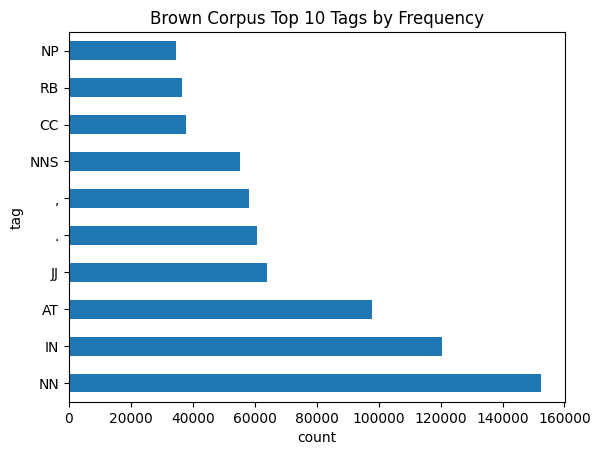

In [174]:
# A test to see the most frequent tags in the corpus.
brown_df["tag"].value_counts().head(10).plot.barh()
plt.title("Brown Corpus Top 10 Tags by Frequency")
plt.xlabel("count")
plt.show()

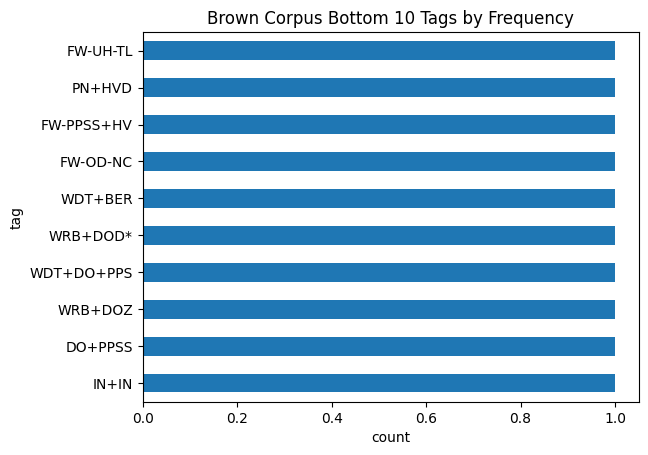

In [186]:
# A test to see the most frequent tags in the corpus.
brown_df["tag"].value_counts().tail(10).plot.barh()
plt.title("Brown Corpus Bottom 10 Tags by Frequency")
plt.xlabel("count")
plt.show()

In [ ]:
# A test to see number of unique tags in Brown base tagset before any modification.

init_tagged_sentences = list(brown.tagged_sents())
init_brown_tags = set(tag for sent in init_tagged_sentences for word, tag in sent)
print(f"Number of POS tags before simplification: {len(init_brown_tags)}")

Number of POS tags before simplification: 472


## Fine-tuning

In [175]:
#We need to reduce / simplify the number of tags in the dataset, otherwise POS classification tasks will be very difficult.
def simplify_tag(tag):
    return tag.split("+")[0].split("-")[0]

tagged_sentences = list(brown.tagged_sents())

#Set means each element is unique, and this means it removes duplicate tags over the collected aggregation of all tags in each sentence in the brown corpus
brown_tags = set(simplify_tag(tag) for sent in tagged_sentences for word, tag in sent)

# We need a numerical class label for each tag in brown_tags to fine-tune DistilBERT.
# We need the tag name for each numerical class label in id_to_tag to interpret classification results.
tag_to_id = {tag: i for i, tag in enumerate(sorted(brown_tags))}
id_to_tag = {i: tag for tag, i in tag_to_id.items()}

print(f"Number of POS tags after simplification: {len(tag_to_id)}")

Number of POS tags after simplification: 105


In [ ]:
# This cell will setup the Brown Corpus in the format of the Hugging Face Dataset (which is used to fine-tune DistilBERT).

data = [
    {
        "tokens": [w for w, _ in sent],
        "tags": [simplify_tag(t) for _, t in sent],
    }
    for sent in tagged_sentences
]

# Each tagged sentence from the Brown Corpus becomes a dictionary, with the tokens list being the words in the sentence, the tags list being the respective tags in the sentence.
dataset = Dataset.from_list(data).train_test_split(test_size=0.2, seed=67)

In [ ]:
# This cell will handle tokenization and label alignment.

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Test tokenization with DistilBERT tokenizer.
print(tokenizer("Computational Linguistics"))

def tokenize_and_align(batch):
    encoding = tokenizer(
        batch["tokens"],
        is_split_into_words=True,
        truncation=True,
        padding=False,
    )
    labels = []
    for i, tags in enumerate(batch["tags"]):
        # Return which original word each token came from because tokenizing breaks words up.
        word_ids = encoding.word_ids(batch_index=i)
        prev_word = None
        label_ids = []
        for wid in word_ids:
            if wid is None:
                # Pytorch loss function ignore, refer to PyTorch docs as to why -100 is considered ignored
                label_ids.append(-100)
            elif wid != prev_word:
                # The first subtoken of a word only contributes to the label.
                label_ids.append(tag_to_id[tags[wid]])
            else:
                # Pytorch loss function ignore, refer to PyTorch docs as to why -100 is considered ignored
                label_ids.append(-100)
            prev_word = wid
        labels.append(label_ids)
    encoding["labels"] = labels
    return encoding

# So now, the dataset will have everything that is needed for the training / fine-tuning process. 
# Here, we can also remove columns that aren't needed for training.
tokenized = dataset.map(
    tokenize_and_align,
    batched=True,
    remove_columns=["tokens", "tags"]
)


{'input_ids': [101, 15078, 15397, 102], 'attention_mask': [1, 1, 1, 1]}


Map:   0%|          | 0/45872 [00:00<?, ? examples/s]

Map:   0%|          | 0/11468 [00:00<?, ? examples/s]

In [178]:
# This cell sets up the DistilBERT model to be fine-tuned.

model = AutoModelForTokenClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels = len(tag_to_id),
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

In [179]:
# This cell sets up training arguments and training of the base DistilBERT model for POS classification.

# If you're doing work on a Mac, you need to support the device for Metal training by uncommenting the line below. It speeds up training significantly, but if on Windows this can be ignored.
# os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1" 

training_args = TrainingArguments(
    output_dir = "distilbert-brown-pos",
    num_train_epochs = 3,
    learning_rate = 2e-5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size = 64,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    log_level="error",
    push_to_hub=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    data_collator=DataCollatorForTokenClassification(tokenizer),
    processing_class=tokenizer,
)


# Uncomment the below line if you want to locally fine-tune DistilBERT. THIS SHOULD ONLY BE UNCOMMENTED if you have a powerful computer or are running on a cloud service with GPU support, otherwise training will be very slow!
# This takes ~15m total on a MacBook Pro M3 Pro with 18GB of unified memory (my laptop).
# trainer.train()

# Uncomment the below line if you want to push the fine-tuned model to HuggingFace. This should never need to be uncommented, as the trained model has already been pushed to the website, and can be accessed at https://huggingface.co/nevertipyourlandlord/distilbert-brown-pos.
# trainer.push_to_hub()

## Evaluation

In [180]:
model_name = "nevertipyourlandlord/distilbert-brown-pos"

# If this runs, I fine-tuned DistilBERT! You can check at https://huggingface.co/nevertipyourlandlord/distilbert-brown-pos too. It currently has about 60 downloads since the model is public, which is pretty cool!
print(model_info(model_name))

# The auto classes make it easy to load my fine-tuned model from HuggingFace.
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)

ModelInfo(id='nevertipyourlandlord/distilbert-brown-pos', author='nevertipyourlandlord', base_models=None, card_data={'base_model': 'distilbert-base-uncased', 'datasets': None, 'eval_results': [], 'language': None, 'library_name': 'transformers', 'license': 'apache-2.0', 'license_name': None, 'license_link': None, 'metrics': None, 'model_name': 'distilbert-brown-pos', 'pipeline_tag': None, 'tags': ['generated_from_trainer']}, children_model_count=None, config={'architectures': ['DistilBertForTokenClassification'], 'model_type': 'distilbert', 'tokenizer_config': {'cls_token': '[CLS]', 'mask_token': '[MASK]', 'pad_token': '[PAD]', 'sep_token': '[SEP]', 'unk_token': '[UNK]'}}, created_at=datetime.datetime(2026, 4, 26, 22, 42, 1, tzinfo=datetime.timezone.utc), disabled=False, downloads=80, downloads_all_time=None, eval_results=None, gated=False, gguf=None, inference=None, inference_provider_mapping=None, last_modified=datetime.datetime(2026, 4, 27, 1, 6, 15, tzinfo=datetime.timezone.utc), 

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

In [181]:
# The technical specifications / eval of the fine-tuned model on HF.

model.eval()

DistilBertForTokenClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
   

In [ ]:
# This cell handles setup for prediction and actual prediction on the test set, which can be used for evals.

collator = DataCollatorForTokenClassification(tokenizer)
dataloader = DataLoader(tokenized["test"], batch_size=64, collate_fn=collator)

predicted_list = []
true_list = []

#Don't need to compute gradients with PyTorch for evals, in order to speed up. We can predict tags within 5min-ish using the fine-tuned DistilBERT model on the test set, and collect the predicted and true tags as lists for sklearn evals
with torch.no_grad():
    for batch in dataloader:
        labels = batch["labels"]
        
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=-1)

        # Ignore pytorch -100 labels, only collect tags for tokens that contibute to loss fcn for training (first subtoken of each word)
        for pred_row, label_row in zip(preds, labels):
            for p, l in zip(pred_row, label_row):
                if l.item() != -100:
                    predicted_list.append(p.item())
                    true_list.append(l.item())

# If there's labels missing from the test set (there's a chance, because test set is 20% of data, picked randomly), we need to ignore them in evals, otherwise metrics throw errors
labels_present = sorted(set(true_list))
label_names_present = [id_to_tag[i] for i in labels_present]

In [183]:
# Classification report shows several metrics which will be discussed below, also, view the below output as a "scrollable element" to see all the tags' performance
print(classification_report(true_list, predicted_list, labels=labels_present, target_names=label_names_present, zero_division=0))

              precision    recall  f1-score   support

                   1.00      1.00      1.00       672
           '       0.89      0.89      0.89        66
          ''       1.00      1.00      1.00      1776
           (       0.99      1.00      1.00       499
           )       0.99      1.00      1.00       521
           *       1.00      1.00      1.00       880
           ,       1.00      1.00      1.00     11756
           .       1.00      1.00      1.00     12227
           :       1.00      1.00      1.00       311
         ABL       0.97      1.00      0.98        62
         ABN       0.94      0.99      0.96       647
         ABX       1.00      1.00      1.00       134
          AP       0.94      0.96      0.95      1897
         AP$       0.00      0.00      0.00         1
          AT       1.00      1.00      1.00     19695
          BE       1.00      1.00      1.00      1253
         BED       1.00      1.00      1.00       663
        BED*       0.00    

The accuracy of 0.98, F1-Macro average of 0.85, and F1-Weighted average of 0.98 over a support (test set size) of 231,659 words indicate that the fine-tuned DistilBERT model performs very well for POS tagging tasks. Refer to the report for further details on the classification report.

Text(0.5, 1.0, 'Confusion Matrix for Fine-Tuned DistilBERT on Brown Corpus POS Tagging')

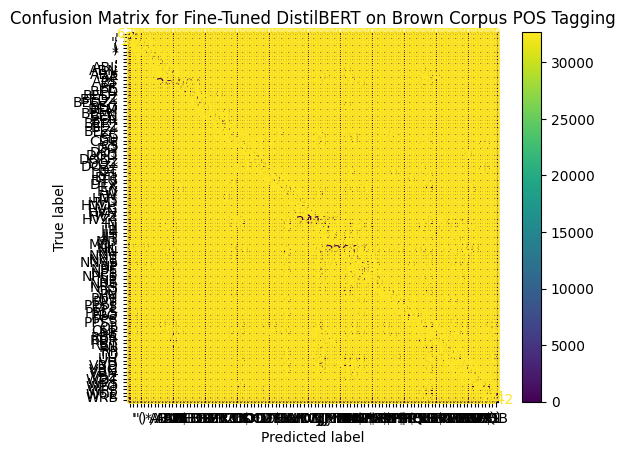

In [184]:
# Confusion Matrix

# For all ~100 tags after tag simplification, still really hard to see in CM format.
# This isn't a great way to visualize the errors, but it does confirm the classification report showing a very high accuracy on token classification tasks (POS tagging).
cm = confusion_matrix(true_list, predicted_list)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names_present).plot()
plt.title("Confusion Matrix for Fine-Tuned DistilBERT on Brown Corpus POS Tagging")

I choose not to include this in the project report due to its unreadability, but you can see above that there are little misclassifications and high correct classifications, indicated by the presence of lots of yellow in each cell in the matrix and little amounts of what seems to be black in some cells in the matrix.

In [188]:
# Counts of the most common errors.
# This evaluation is more interpretable than the confusion matrix for the amount of tags we have.

errors = Counter(
    (id_to_tag[t], id_to_tag[p])
    for t, p in zip(true_list, predicted_list)
    if t != p
)
print("Most common 10 errors using the fine-tuned DistilBERT for prediction on the test set (true, pred):")
errors.most_common(10)

Most common 10 errors using the fine-tuned DistilBERT for prediction on the test set (true, pred):


[(('NN', 'JJ'), 233),
 (('NP', 'NN'), 188),
 (('JJ', 'NN'), 183),
 (('NN', 'NP'), 121),
 (('QL', 'RB'), 113),
 (('RB', 'QL'), 100),
 (('VBN', 'VBD'), 96),
 (('IN', 'CS'), 84),
 (('CS', 'IN'), 72),
 (('VBD', 'VBN'), 71)]

I format the above 10 misclassifications cleanly as a table in the project report PDF and discuss a bit further about why this might be linguistically happening there (hint: words are being mistaken for another!). As a discussion here in the notebook, we notably see that the most common misclassification is the model predicting a noun (NN) when the true tag is an adjective (JJ), which occurs 233 times in the test split. Secondly, we can see that the second most common misclassification is the model predicting a proper noun (NP) when the true tag is a noun (NN), which occurs 188 times. There is a lot of data to explain here, so I will not explain it all, but I believe that there may be more preprocessing that needs to be done on this type of model in order to obtain the highest accuracy possible, because we could for instance collapse NN and NP into N for just a general noun. Another example would be collapsing the 10th most common misclassification from VBD (past tense verb) and VBN (past participle verb) into just VB (verb). This would likely require a lot of work to get a little performance boost, which is why this is not feasible for the current project. See below for examples of sentence comparison between PerceptronTagger and DistilBERT.

### Bonus Round

In [ ]:
# This cell handles some tests of NLTK Perceptron Tagger vs my fine-tuned DistilBERT model for POS tagging on some sentences of my choice.
# This is explained in more detail here instead of the report, as this is more of a bonus / future work thing that would be interesting to look into.

nltk.download('averaged_perceptron_tagger_eng')

pretrained_perceptron_tagger = PerceptronTagger()

test_sentences = [
    "fish fish fish fish fish",
    "learning computational linguistics",
    "book bags are not both nouns",
    "hello professor"
]

# For each sentence we want to compare the tagging by eye, and see what differs
for sent in test_sentences:
    print(f"Test sentence: '{sent}'")
    print("NLTK's Perceptron Tagger:", pretrained_perceptron_tagger.tag(sent.split()))

    inputs = tokenizer(sent.split(), is_split_into_words=True, return_tensors="pt")
    
    # No gradients again for PyTorch to speed up since we're just doing prediction.
    with torch.no_grad():
        outputs = model(**inputs)
    
    predictions = outputs.logits.argmax(dim=-1)[0].tolist()
    word_ids = inputs.word_ids()

    aligned_tags = [
        id_to_tag[predictions[i]]
        for i, wid in enumerate(word_ids)
        if wid is not None  # skips [CLS] and [SEP]
    ]
    
    print("My fine-tuned DistilBERT:", list(zip(sent.split(), aligned_tags)))

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Owner\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Test sentence: 'fish fish fish fish fish'
NLTK's Perceptron Tagger: [('fish', 'JJ'), ('fish', 'JJ'), ('fish', 'NN'), ('fish', 'NN'), ('fish', 'NN')]
My fine-tuned DistilBERT: [('fish', 'NN'), ('fish', 'NN'), ('fish', 'NN'), ('fish', 'NN'), ('fish', 'NN')]
Test sentence: 'learning computational linguistics'
NLTK's Perceptron Tagger: [('learning', 'VBG'), ('computational', 'JJ'), ('linguistics', 'NNS')]
My fine-tuned DistilBERT: [('learning', 'VBG'), ('computational', 'JJ'), ('linguistics', 'NN')]
Test sentence: 'book bags are not both nouns'
NLTK's Perceptron Tagger: [('book', 'NN'), ('bags', 'NNS'), ('are', 'VBP'), ('not', 'RB'), ('both', 'DT'), ('nouns', 'NNS')]
My fine-tuned DistilBERT: [('book', 'NN'), ('bags', 'NNS'), ('are', 'BER'), ('not', '*'), ('both', 'ABX'), ('nouns', 'NNS')]
Test sentence: 'hello professor'
NLTK's Perceptron Tagger: [('hello', 'NN'), ('professor', 'NN')]
My fine-tuned DistilBERT: [('hello', 'UH'), ('professor', 'NN')]


There are only 36 POS tags in the Penn Treebank / Perceptron Tagger tagset according to https://www.ling.upenn.edu/courses/Fall_2003/ling001/penn_treebank_pos.html! 

Since the base Brown Corpus tagset has 472 tags as calculated above (and 105 when condensed), there could be an issue of the models being on different tagsets, which might help to fix for these types of comparisons. This is also the reason for why I am not calculating any scores for the above cell.

Now for some linguistic analysis:

Test sentence: 'fish fish fish fish fish'

NLTK's Perceptron Tagger: [('fish', 'JJ'), ('fish', 'JJ'), ('fish', 'NN'), ('fish', 'NN'), ('fish', 'NN')]

My fine-tuned DistilBERT: [('fish', 'NN'), ('fish', 'NN'), ('fish', 'NN'), ('fish', 'NN'), ('fish', 'NN')]

NLTK is probably a tiny little bit better here, even if it does tag the first two fish as adjectives (JJ) which is wrong, also it does not mention any fish verb, but it does seem to somehow get context from the sentence by putting the first two fish as adjectives which is more correct than just nouns. DistilBERT doesn't have any verbs, opting to do only nouns.

Test sentence: 'learning computational linguistics'

NLTK's Perceptron Tagger: [('learning', 'VBG'), ('computational', 'JJ'), ('linguistics', 'NNS')]

My fine-tuned DistilBERT: [('learning', 'VBG'), ('computational', 'JJ'), ('linguistics', 'NN')]

This is actually pretty close, the debate is saying Perceptron Tagger thinks 'linguistics' is a plural noun (NNS), but my DistilBERT thinks 'linguistics' is a singular noun (NN). I would say that my fine-tuned model is better than NLTK here, because you wouldn't for instance say 'two linguistics' like you would for a plural noun like 'two dogs', I would think it's more in line with being a singular noun (NN). 

So the score is 1-1 right now!

Test sentence: 'book bags are not both nouns'

NLTK's Perceptron Tagger: [('book', 'NN'), ('bags', 'NNS'), ('are', 'VBP'), ('not', 'RB'), ('both', 'DT'), ('nouns', 'NNS')]

My fine-tuned DistilBERT: [('book', 'NN'), ('bags', 'NNS'), ('are', 'BER'), ('not', '*'), ('both', 'ABX'), ('nouns', 'NNS')]

The differences in this sentence are for the words 'are', 'not', 'both'. I believe that this is just a tagset difference, but it's still comparable. For 'are', PerceptronTagger says VBP, which I believe to be present tense-verb, and DistilBERT says BER, which is the tag for 'are'. So DistilBERT is a little closer here, since it's more specific. For 'not', PerceptronTagger says 'RB' which is an adverb, and '*' which I believe is negation. Again, both are right but DistilBERT is a little closer since 'not' negates the next phrase. For 'both', PerceptronTagger says DT which is a determiner, and DistilBERT says ABX which is 'determiner/pronoun, double conjunction or pre-quantifier' according to https://www.survivor99.com/pscience/2007-7/brown_corpus_tag.htm, also listing 'both' as an example, so I'll give it to my model here. Also, note that the 'book bags' are getting classified by both models as a singular noun going into a plural noun, which should be correct, but I wanted to be a bit humorous and spark some debate and see if the models would respond incorrectly.

The score is now 2-1 in my favor against NLTK.

Test sentence: 'hello professor'

NLTK's Perceptron Tagger: [('hello', 'NN'), ('professor', 'NN')]

My fine-tuned DistilBERT: [('hello', 'UH'), ('professor', 'NN')]

The difference in this sentence is for the word 'hello', PerceptronTagger treats it as a noun (NN), while DistilBERT treats it as a interjection (UH). Since hello is meant to be a greeting toward the unnamed professor currently reading this cell (Professor Danis), I'd think that an interjection is closer to the true POS tag category for the word in this context.

3-1 for me against NLTK, so I think my model is a bit more specific/better at sentences.

The above show that the context given to a Transformers-based model (like my DistilBERT) might have an edge in sentence-level POS prediction, because the prediction for a word is based off of the other words in the sentence for a model like DistilBERT, but not for a more simple/standard model like the PerceptronTagger. I do believe that there are limitations, however, due to the differences in the tagsets/datasets between the two models, so there's not a substantial amount of evidence for now.